In [51]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('egypt_tourism_dataset.csv')

print(df.head())

print('Shape:', df.shape)

print(df.dtypes)


  tourist_id  age  gender nationality city_visited  trip_duration_days  \
0     T00001   15  Female     Germany        Cairo                   9   
1     T00002   16    Male      Canada     Hurghada                   8   
2     T00003   11  Female     Germany        Luxor                   3   
3     T00004    5  Female      Norway        Aswan                  10   
4     T00005   11    Male          UK        Cairo                   6   

   season       travel_company  total_spending_usd  
0  Spring  Galaxy Travel Egypt            1,658.99  
1  Autumn       King Tut Tours            2,309.34  
2  Spring  Classic Tours Egypt              594.10  
3  Summer  Falcon Travel Egypt            2,985.73  
4  Summer    Nile Travel Egypt              894.90  
Shape: (10000, 9)
tourist_id                str
age                     int64
gender                    str
nationality               str
city_visited              str
trip_duration_days      int64
season                    str
travel_co

In [28]:
print('Missing values:')
print(df.isna().sum())

print('\nMissing percentage:')
print((df.isna().mean() * 100).round(2))

print('\nDuplicate rows:', df.duplicated().sum())

print('\nUnique values count:')
print(df.nunique())


Missing values:
tourist_id            0
age                   0
gender                0
nationality           0
city_visited          0
trip_duration_days    0
season                0
travel_company        0
total_spending_usd    0
dtype: int64

Missing percentage:
tourist_id           0.00
age                  0.00
gender               0.00
nationality          0.00
city_visited         0.00
trip_duration_days   0.00
season               0.00
travel_company       0.00
total_spending_usd   0.00
dtype: float64

Duplicate rows: 0

Unique values count:
tourist_id            10000
age                      14
gender                    2
nationality              12
city_visited              6
trip_duration_days        9
season                    4
travel_company          111
total_spending_usd     9742
dtype: int64


In [29]:
print('Statistical summary:')
display(df[['age', 'trip_duration_days', 'total_spending_usd']].describe())

print('Gender values:')
print(df['gender'].value_counts())

print('\nNationality values:')
print(df['nationality'].value_counts())

print('\nCities values:')
print(df['city_visited'].value_counts())

print('\nSeasons values:')
print(df['season'].value_counts())


Statistical summary:


,age,trip_duration_days,total_spending_usd
count,"10,000.00","10,000.00","10,000.00"
mean,12.03,5.98,"1,135.66"
std,4.05,2.59,643.34
min,5.00,2.00,160.19
25%,9.00,4.00,623.53
50%,13.00,6.00,"1,017.32"
75%,16.00,8.00,"1,513.08"
max,18.00,10.00,"3,499.98"


Gender values:
gender
Female    5066
Male      4934
Name: count, dtype: int64

Nationality values:
nationality
Spain          878
UK             858
USA            835
Australia      834
France         834
Germany        832
Italy          831
Sweden         823
Canada         822
Norway         818
Denmark        818
Netherlands    817
Name: count, dtype: int64

Cities values:
city_visited
Cairo              1701
Hurghada           1691
Aswan              1674
Luxor              1664
Sharm El Sheikh    1642
Alexandria         1628
Name: count, dtype: int64

Seasons values:
season
Spring    2520
Winter    2519
Summer    2503
Autumn    2458
Name: count, dtype: int64


In [30]:
Q1 = df['total_spending_usd'].quantile(0.25)
Q3 = df['total_spending_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)

outlier_condition = (
    (df['total_spending_usd'] < lower_bound) |
    (df['total_spending_usd'] > upper_bound)
)

print('Number of outliers:', outlier_condition.sum())


Q1: 623.53
Q3: 1513.0774999999999
IQR: 889.5474999999999
Lower bound: -710.79125
Upper bound: 2847.39875
Number of outliers: 143


In [31]:
outliers_df = df[outlier_condition].copy()

outliers_df = outliers_df.sort_values(
    by='total_spending_usd',
    ascending=False
)

display(outliers_df.head(20))


,tourist_id,age,gender,nationality,city_visited,trip_duration_days,season,travel_company,total_spending_usd
7418,T07419,6,Male,France,Sharm El Sheikh,10,Summer,Superior Travel Egypt,"3,499.98"
1014,T01015,12,Female,Canada,Sharm El Sheikh,10,Spring,Superior Travel Egypt,"3,497.30"
2282,T02283,6,Male,Italy,Sharm El Sheikh,10,Winter,Classic Tours Egypt,"3,466.46"
6859,T06860,10,Male,Canada,Sharm El Sheikh,10,Summer,Future Travel Egypt,"3,463.17"
766,T00767,11,Female,Sweden,Sharm El Sheikh,10,Autumn,Abercrombie & Kent Egypt,"3,447.92"
5943,T05944,5,Female,Spain,Sharm El Sheikh,10,Spring,Classic Tours Egypt,"3,447.39"
565,T00566,11,Female,Canada,Sharm El Sheikh,10,Winter,Luxor and Aswan Travel,"3,405.09"
6656,T06657,9,Male,Australia,Sharm El Sheikh,10,Spring,Egypt Tailor Made Tours,"3,400.61"
6154,T06155,15,Male,UK,Sharm El Sheikh,10,Summer,Emo Tours Egypt,"3,378.67"
7945,T07946,17,Female,USA,Sharm El Sheikh,10,Winter,Emo Tours Egypt,"3,375.83"


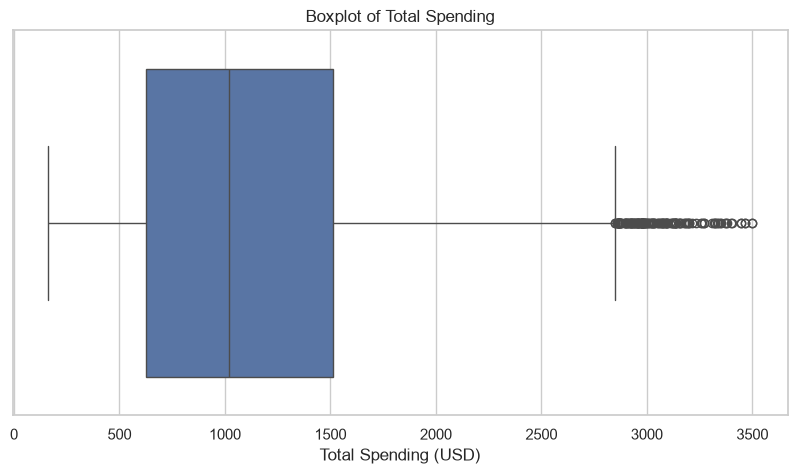

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['total_spending_usd'])
plt.title('Boxplot of Total Spending')
plt.xlabel('Total Spending (USD)')
plt.show()


In [33]:
# زودت عمود يحدد هل الإنفاق اوتلاير ولا لا
df['spending_outlier_iqr'] = outlier_condition

# حساب متوسط إنفاق السائح في اليوم
df['spending_per_day_usd'] = (
    df['total_spending_usd'] / df['trip_duration_days']
).round(2)

# عرض الأعمدة الجديدة مع البيانات الأساسية
display(df[[
    'tourist_id',
    'trip_duration_days',
    'total_spending_usd',
    'spending_per_day_usd',
    'spending_outlier_iqr'
]].head(10))


,tourist_id,trip_duration_days,total_spending_usd,spending_per_day_usd,spending_outlier_iqr
0,T00001,9,"1,658.99",184.33,False
1,T00002,8,"2,309.34",288.67,False
2,T00003,3,594.10,198.03,False
3,T00004,10,"2,985.73",298.57,True
4,T00005,6,894.90,149.15,False
5,T00006,10,"2,098.53",209.85,False
6,T00007,7,706.81,100.97,False
7,T00008,6,583.74,97.29,False
8,T00009,6,"1,003.58",167.26,False
9,T00010,8,"1,294.92",161.86,False


In [34]:
print('Final shape:', df.shape)
print('Total missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('\nColumns:')
print(df.columns.tolist())

print('\nOutlier flag counts:')
print(df['spending_outlier_iqr'].value_counts())

output_file = 'egypt_tourism_preprocessed.csv'
df.to_csv(output_file, index=False)
print(f'\nSaved successfully as: {output_file}')


Final shape: (10000, 11)
Total missing values: 0
Duplicate rows: 0

Columns:
['tourist_id', 'age', 'gender', 'nationality', 'city_visited', 'trip_duration_days', 'season', 'travel_company', 'total_spending_usd', 'spending_outlier_iqr', 'spending_per_day_usd']

Outlier flag counts:
spending_outlier_iqr
False    9857
True      143
Name: count, dtype: int64

Saved successfully as: egypt_tourism_preprocessed.csv


In [35]:
hotels = pd.read_csv('Egypt_hotels_data.csv')

print(hotels.head())

print('\nShape:', hotels.shape)

print('\nData types:')
print(hotels.dtypes)

print('\nMissing values:')
print(hotels.isna().sum().sort_values(ascending=False))

print('\nDuplicate rows:', hotels.duplicated().sum())


              Type                      Name  \
0  vacation rental        Pyramids Power Inn   
1            hotel  Best View Pyramids Hotel   
2  vacation rental                     Dahab   
3  vacation rental          oasis hot spring   
4            hotel        egypt pyramids inn   

                                                                                                                      Link  \
0  https://www.bluepillow.com/search?p_id=589dfad07c00cb10c8daaa72&dest=bkng&cat=House&accomodationids=594389447c00cb0e...   
1                                                                  https://sites.google.com/view/best-view-pyramids-hotel/   
2                                                                                                                      NaN   
3  https://www.bluepillow.com/search?p_id=589dfacc7c00cb10c8daaa1e&dest=bkng&cat=Apartment&accomodationids=654cb3633011...   
4                                                                        https://

In [36]:
hotels.columns = (
    hotels.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print(hotels.columns.tolist())


['type', 'name', 'link', 'latitude', 'longitude', 'check_in_time', 'check_out_time', 'overall_rating', 'reviews', 'location_rating', 'amenities', 'excluded_amenities', 'essential_info', 'nearby_places', 'ratings_breakdown', 'reviews_breakdown', 'rate_per_night_lowest', 'rate_per_night_before_taxes_and_fees', 'total_rate_lowest', 'total_rate_before_taxes_and_fees']


In [37]:
before = len(hotels)

hotels = hotels.drop_duplicates().copy()

after = len(hotels)
print('Rows before:', before)
print('Rows after:', after)
print('Duplicate rows removed:', before - after)


Rows before: 947
Rows after: 732
Duplicate rows removed: 215


In [38]:
import re
import numpy as np


def extract_egp(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = value.replace(',', '')
    value = re.sub(r'[^0-9.]', '', value)

    return float(value) if value else np.nan

price_columns = [
    'rate_per_night_lowest',
    'rate_per_night_before_taxes_and_fees',
    'total_rate_lowest',
    'total_rate_before_taxes_and_fees'
]

for col in price_columns:
    hotels[col + '_egp'] = hotels[col].apply(extract_egp)

price_check_columns = [
    'rate_per_night_lowest',
    'rate_per_night_lowest_egp',
    'total_rate_lowest',
    'total_rate_lowest_egp'
]

display(hotels[price_check_columns].head(10))


,rate_per_night_lowest,rate_per_night_lowest_egp,total_rate_lowest,total_rate_lowest_egp
0,"EGP 1,499","1,499.00","EGP 1,499","1,499.00"
1,"EGP 1,964","1,964.00","EGP 1,964","1,964.00"
2,"EGP 1,108","1,108.00","EGP 1,108","1,108.00"
3,EGP 708,708.00,EGP 708,708.00
4,"EGP 2,360","2,360.00","EGP 2,360","2,360.00"
5,"EGP 4,920","4,920.00","EGP 4,920","4,920.00"
6,"EGP 3,197","3,197.00","EGP 3,197","3,197.00"
7,"EGP 11,979","11,979.00","EGP 11,979","11,979.00"
8,"EGP 3,787","3,787.00","EGP 3,787","3,787.00"
9,"EGP 16,946","16,946.00","EGP 16,946","16,946.00"


In [39]:
hotels['price_per_night_egp'] = hotels['total_rate_lowest_egp'].fillna(
    hotels['rate_per_night_lowest_egp']
)

hotels['price_available'] = hotels['price_per_night_egp'].notna()

print('Available prices:', hotels['price_available'].sum())
print('Missing prices:', hotels['price_available'].eq(False).sum())

print('\nPrice summary:')
display(hotels['price_per_night_egp'].describe())


Available prices: 613
Missing prices: 119

Price summary:


count      613.00
mean     4,396.91
std      7,808.51
min        188.00
25%        856.00
50%      1,506.00
75%      4,526.00
max     67,163.00
Name: price_per_night_egp, dtype: float64

In [40]:
price_median = hotels['price_per_night_egp'].median()
print('Price median before imputation:', price_median)

hotels['price_was_missing'] = hotels['price_per_night_egp'].isna()# السعر مش حقيقي 

hotels['price_per_night_egp'] = hotels['price_per_night_egp'].fillna(price_median)

print('Missing prices before imputation:', hotels['price_was_missing'].sum())
print('Missing prices after imputation:', hotels['price_per_night_egp'].isna().sum())
print('Number of imputed prices:', hotels['price_was_missing'].sum())


Price median before imputation: 1506.0
Missing prices before imputation: 119
Missing prices after imputation: 0
Number of imputed prices: 119


In [41]:
print('Zero overall ratings:', (hotels['overall_rating'] == 0).sum())
print('Zero location ratings:', (hotels['location_rating'] == 0).sum())
print('Zero reviews:', (hotels['reviews'] == 0).sum())

display(
    hotels.loc[
        (hotels['overall_rating'] == 0) | (hotels['reviews'] == 0),
        ['name', 'overall_rating', 'location_rating', 'reviews']
    ].head(20)
)


Zero overall ratings: 113
Zero location ratings: 1
Zero reviews: 113


,name,overall_rating,location_rating,reviews
2,Dahab,0.00,3.00,0
3,oasis hot spring,0.00,3.10,0
39,Mini house pyramids view,0.00,4.00,0
59,Romantic Spanish villa w/hot tub — 5 min from the beach,0.00,3.20,0
117,Alzohour Family condo with panoramic sea view,0.00,3.20,0
194,Pyramids View Hotel,0.00,2.40,0
202,Pyramids View Hotel,0.00,2.40,0
219,pyramids gardens guest house - Luxury Triple Room,0.00,2.40,0
238,pyramids gardens guest house - Luxury Triple Room,0.00,2.40,0
283,Kamosse pyramids view,0.00,4.10,0


In [42]:
hotels['rating_was_missing'] = (
    (hotels['overall_rating'] == 0) |
    (hotels['reviews'] == 0)
)

hotels['location_rating_was_missing'] = (
    hotels['location_rating'] == 0
)

hotels.loc[hotels['overall_rating'] == 0, 'overall_rating'] = np.nan
hotels.loc[hotels['location_rating'] == 0, 'location_rating'] = np.nan

print('Missing overall ratings:', hotels['overall_rating'].isna().sum())
print('Missing location ratings:', hotels['location_rating'].isna().sum())
print('Missing reviews:', hotels['reviews'].isna().sum())


Missing overall ratings: 113
Missing location ratings: 1
Missing reviews: 0


In [43]:
text_columns_to_fill = [
    'check_in_time',
    'check_out_time',
    'amenities',
    'excluded_amenities',
    'essential_info',
    'nearby_places',
    'ratings_breakdown',
    'reviews_breakdown'
]

for col in text_columns_to_fill:
    hotels[col + '_was_missing'] = hotels[col].isna()

for col in text_columns_to_fill:
    hotels[col] = hotels[col].fillna('Unknown')


print(hotels.isna().sum().sort_values(ascending=False).head(20))


link                                        315
rate_per_night_before_taxes_and_fees_egp    137
total_rate_before_taxes_and_fees_egp        137
total_rate_before_taxes_and_fees            137
rate_per_night_before_taxes_and_fees        137
rate_per_night_lowest_egp                   119
total_rate_lowest_egp                       119
total_rate_lowest                           119
rate_per_night_lowest                       119
overall_rating                              113
location_rating                               1
name                                          0
type                                          0
longitude                                     0
latitude                                      0
essential_info                                0
reviews                                       0
check_in_time                                 0
excluded_amenities                            0
amenities                                     0
dtype: int64


In [44]:
numeric_price_columns = [
    'rate_per_night_lowest_egp',
    'rate_per_night_before_taxes_and_fees_egp',
    'total_rate_lowest_egp',
    'total_rate_before_taxes_and_fees_egp'
]

for col in numeric_price_columns:
    hotels[col + '_was_missing'] = hotels[col].isna()

    median_value = hotels[col].median()
    hotels[col] = hotels[col].fillna(median_value)

    print(col, 'median used:', median_value)
    print(col, 'missing after imputation:', hotels[col].isna().sum())


rate_per_night_lowest_egp median used: 1506.0
rate_per_night_lowest_egp missing after imputation: 0
rate_per_night_before_taxes_and_fees_egp median used: 1179.0
rate_per_night_before_taxes_and_fees_egp missing after imputation: 0
total_rate_lowest_egp median used: 1506.0
total_rate_lowest_egp missing after imputation: 0
total_rate_before_taxes_and_fees_egp median used: 1179.0
total_rate_before_taxes_and_fees_egp missing after imputation: 0


In [45]:
Q1_price = hotels['price_per_night_egp'].quantile(0.25)
Q3_price = hotels['price_per_night_egp'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price_bound = max(0, Q1_price - 1.5 * IQR_price)
upper_price_bound = Q3_price + 1.5 * IQR_price

hotels['price_outlier_iqr'] = (
    (hotels['price_per_night_egp'] < lower_price_bound) |
    (hotels['price_per_night_egp'] > upper_price_bound)
)

print('Q1:', Q1_price)
print('Q3:', Q3_price)
print('IQR:', IQR_price)
print('Lower bound:', lower_price_bound)
print('Upper bound:', upper_price_bound)
print('Number of price outliers:', hotels['price_outlier_iqr'].sum())


Q1: 939.75
Q3: 3739.0
IQR: 2799.25
Lower bound: 0
Upper bound: 7937.875
Number of price outliers: 86


In [46]:
price_outliers = hotels[
    hotels['price_outlier_iqr'] == True
].sort_values(
    by='price_per_night_egp',
    ascending=False
)

display(price_outliers[[
    'name',
    'type',
    'price_per_night_egp',
    'price_was_missing',
    'overall_rating',
    'reviews'
]].head(20))


,name,type,price_per_night_egp,price_was_missing,overall_rating,reviews
354,فنادير باي,hotel,"67,163.00",False,4.40,161
386,Royal Esadora M/S,hotel,"63,269.00",False,4.40,113
389,Nubian Village Hotel,hotel,"53,596.00",False,4.50,4244
314,Nubian Village Hotel,hotel,"53,596.00",False,4.50,4244
335,Nubian Village Hotel,hotel,"53,596.00",False,4.50,4244
151,Rixos Sharm El Sheikh,hotel,"49,564.00",False,4.90,36285
164,Rixos Sharm El Sheikh,hotel,"49,557.00",False,4.90,36285
152,Four Seasons Resort Sharm El Sheikh,hotel,"40,102.00",False,4.70,2800
317,The St. Regis Cairo,hotel,"37,286.00",False,4.70,4524
388,The St. Regis Cairo,hotel,"37,186.00",False,4.70,4524


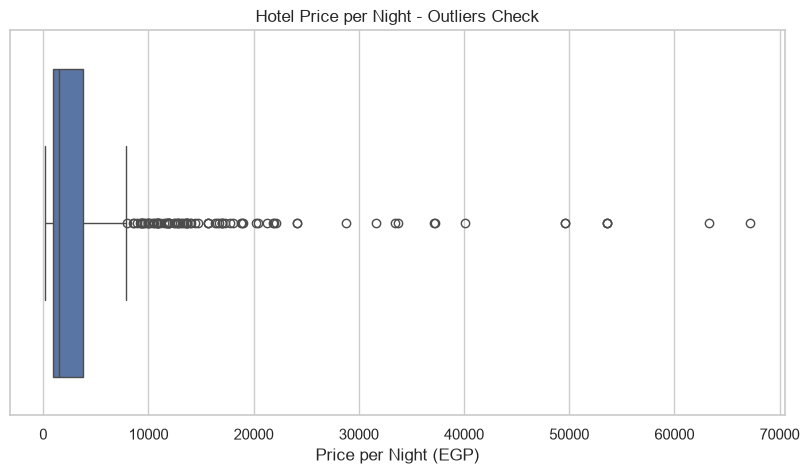

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=hotels['price_per_night_egp'])
plt.title('Hotel Price per Night - Outliers Check')
plt.xlabel('Price per Night (EGP)')
plt.show()


In [48]:
hotels['name_key'] = hotels['name'].str.lower().str.strip()

similar_duplicates = hotels[
    hotels.duplicated(
        subset=['name_key', 'latitude', 'longitude'],
        keep=False
    )
].sort_values(['name_key', 'latitude', 'longitude'])

print('Number of possible same-property records:', len(similar_duplicates))
display(similar_duplicates[[
    'name',
    'type',
    'latitude',
    'longitude',
    'price_per_night_egp',
    'overall_rating',
    'reviews'
]].head(30))


Number of possible same-property records: 126


,name,type,latitude,longitude,price_per_night_egp,overall_rating,reviews
16,Abo Stait - Pyramid View Homestay,vacation rental,29.98,31.14,605.00,4.30,10
23,Abo Stait - Pyramid View Homestay,vacation rental,29.98,31.14,605.00,4.30,10
535,Al Waha Hotel Downtown,hotel,30.05,31.24,558.00,5.00,1
725,Al Waha Hotel Downtown,hotel,30.05,31.24,557.00,5.00,1
234,Almasa Capital,hotel,30.00,31.73,"15,694.00",4.50,2525
466,Almasa Capital,hotel,30.00,31.73,"15,691.00",4.50,2525
67,BenBen By Dhara Hotels,hotel,24.02,32.88,"9,248.00",4.50,257
304,BenBen By Dhara Hotels,hotel,24.02,32.88,"9,609.00",4.50,257
764,Bowling,vacation rental,27.19,33.83,857.00,4.65,15
778,Bowling,vacation rental,27.19,33.83,857.00,4.65,15


In [49]:
hotels['property_key'] = (
    hotels['name_key'].astype(str)
    + '_' + hotels['latitude'].round(5).astype(str)
    + '_' + hotels['longitude'].round(5).astype(str)
)

print('Total records:', len(hotels))
print('Unique properties:', hotels['property_key'].nunique())
print('Repeated property records:', hotels['property_key'].duplicated().sum())


Total records: 732
Unique properties: 663
Repeated property records: 69


In [50]:
hotels = hotels.drop(columns=['name_key'])

print('Final shape:', hotels.shape)
print('Total records:', len(hotels))
print('Unique properties:', hotels['property_key'].nunique())
print('Exact duplicate rows:', hotels.duplicated().sum())

print('\nMissing values:')
print(hotels.isna().sum().sort_values(ascending=False).head(20))

print('\nPrice outliers:', hotels['price_outlier_iqr'].sum())
print('Prices imputed:', hotels['price_was_missing'].sum())
print('Ratings missing:', hotels['rating_was_missing'].sum())

hotels.to_csv('Egypt_hotels_preprocessed.csv', index=False)
print('\nSaved successfully as: Egypt_hotels_preprocessed.csv')


Final shape: (732, 43)
Total records: 732
Unique properties: 663
Exact duplicate rows: 0

Missing values:
link                                    315
total_rate_before_taxes_and_fees        137
rate_per_night_before_taxes_and_fees    137
rate_per_night_lowest                   119
total_rate_lowest                       119
overall_rating                          113
location_rating                           1
name                                      0
type                                      0
latitude                                  0
longitude                                 0
amenities                                 0
reviews                                   0
check_in_time                             0
check_out_time                            0
ratings_breakdown                         0
nearby_places                             0
essential_info                            0
excluded_amenities                        0
reviews_breakdown                         0
dtype: int64

